In [6]:
!pip install matplotlib

Defaulting to user installation because normal site-packages is not writeable
   ---------------------------------------- 0.0/8.1 MB ? eta -:--:--
   ---------------------------------------  8.1/8.1 MB 54.8 MB/s eta 0:00:01
   ---------------------------------------- 8.1/8.1 MB 29.0 MB/s  0:00:00
   ---------------------------------------- 0.0/2.3 MB ? eta -:--:--
   ---------------------------------------- 2.3/2.3 MB 21.8 MB/s  0:00:00
   ---------------------------------------- 0.0/7.0 MB ? eta -:--:--
   -------------------------------------- - 6.8/7.0 MB 40.1 MB/s eta 0:00:01
   ---------------------------------------- 7.0/7.0 MB 23.8 MB/s  0:00:00

   ----- ---------------------------------- 1/7 [pillow]
   ----- ---------------------------------- 1/7 [pillow]
   ----- ---------------------------------- 1/7 [pillow]
   ----- ---------------------------------- 1/7 [pillow]
   ----------------- ---------------------- 3/7 [fonttools]
   ----------------- ---------------------- 3/7 [f


[notice] A new release of pip is available: 25.3 -> 26.0.1
[notice] To update, run: C:\Users\cms\AppData\Local\Microsoft\WindowsApps\PythonSoftwareFoundation.Python.3.13_qbz5n2kfra8p0\python.exe -m pip install --upgrade pip


In [7]:
import pandas as pd
import matplotlib.pyplot as plt


EDA:

1. Cargar y explorar el dataset
2. Limpiar y preparar los datos
3. Analizar y visualizar los datos
4. Extraer conclusiones

In [10]:
#Cargar dataset

titanic = pd.read_csv("titanic_clase4.csv")
titanic

,nombre,sobrevivio,clase,sexo,edad,tarifa,embarcacion,cabina
0,Jack Dawson,0,3,male,20.0,7.25,S,NaN
1,Rose DeWitt,1,1,female,17.0,512.33,C,B57
2,John Smith,0,2,male,35.0,13.00,S,NaN
3,Mary Johnson,1,1,female,28.0,76.29,C,C85
4,Thomas Brown,0,3,male,NaN,8.05,S,NaN
5,Elisabeth Jones,1,1,female,45.0,35.50,S,C103
6,William Davis,0,3,male,23.0,7.92,Q,NaN
7,Sarah Wilson,1,2,female,31.0,21.00,S,NaN
8,James Miller,0,3,male,NaN,7.75,Q,NaN
9,Emma Moore,1,1,female,22.0,151.55,S,B45


In [11]:
# Exploración inicial

titanic.info()

<class 'pandas.DataFrame'>
RangeIndex: 31 entries, 0 to 30
Data columns (total 8 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   nombre       31 non-null     str    
 1   sobrevivio   31 non-null     int64  
 2   clase        31 non-null     int64  
 3   sexo         31 non-null     str    
 4   edad         27 non-null     float64
 5   tarifa       31 non-null     float64
 6   embarcacion  31 non-null     str    
 7   cabina       11 non-null     str    
dtypes: float64(2), int64(2), str(4)
memory usage: 2.1 KB


In [12]:
# VAriables numericas con descripciones estadisticas básicas

titanic.describe()


,sobrevivio,clase,edad,tarifa
count,31.000000,31.000000,27.000000,31.000000
mean,0.516129,2.129032,33.222222,52.375161
std,0.508001,0.921663,11.056962,98.678691
min,0.000000,1.000000,17.000000,7.250000
25%,0.000000,1.000000,25.000000,7.920000
50%,1.000000,2.000000,33.000000,13.000000
75%,1.000000,3.000000,39.000000,55.700000
max,1.000000,3.000000,62.000000,512.330000


In [13]:
titanic.isnull().sum()

nombre          0
sobrevivio      0
clase           0
sexo            0
edad            4
tarifa          0
embarcacion     0
cabina         20
dtype: int64

In [14]:
titianic_nuevo = titanic.drop(columns=["cabina"])
titianic_nuevo = titianic_nuevo.drop_duplicates()

In [17]:
# Qué hacer con edad?

mediana_edad = titianic_nuevo["edad"].median()
print(f"Mediana de edad: {mediana_edad}")

Mediana de edad: 32.0


In [25]:
titianic_nuevo["edad"] = titianic_nuevo ["edad"].fillna(mediana_edad)
print(f"Filas y columnas despues de limpiar: {titianic_nuevo.shape}")
titianic_nuevo.info()

Filas y columnas despues de limpiar: (30, 7)
<class 'pandas.DataFrame'>
RangeIndex: 30 entries, 0 to 29
Data columns (total 7 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   nombre       30 non-null     str    
 1   sobrevivio   30 non-null     int64  
 2   clase        30 non-null     int64  
 3   sexo         30 non-null     str    
 4   edad         30 non-null     float64
 5   tarifa       30 non-null     float64
 6   embarcacion  30 non-null     str    
dtypes: float64(2), int64(2), str(3)
memory usage: 1.8 KB


In [26]:
titianic_nuevo["edad"]

0     20.0
1     17.0
2     35.0
3     28.0
4     32.0
5     45.0
6     23.0
7     31.0
8     32.0
9     22.0
10    42.0
11    26.0
12    19.0
13    55.0
14    29.0
15    38.0
16    32.0
17    33.0
18    40.0
19    24.0
20    36.0
21    29.0
22    47.0
23    21.0
24    33.0
25    62.0
26    32.0
27    27.0
28    44.0
29    36.0
Name: edad, dtype: float64

In [29]:
#Crear grupo de edades para otro analisis

titianic_nuevo["edad_grupo"] = pd.cut(
    titianic_nuevo["edad"],
    bins = [0, 25, 40, 100],
    labels=["joven", "adulto", "mayor"]
)

titianic_nuevo[["edad", "edad_grupo"]].head(30)

,edad,edad_grupo
0,20.0,joven
1,17.0,joven
2,35.0,adulto
3,28.0,adulto
4,32.0,adulto
5,45.0,mayor
6,23.0,joven
7,31.0,adulto
8,32.0,adulto
9,22.0,joven


In [30]:
# Cambiar tipo de datos de edad de float a int

titianic_nuevo["edad"] = titianic_nuevo["edad"].astype(int)
titianic_nuevo.info()

<class 'pandas.DataFrame'>
RangeIndex: 30 entries, 0 to 29
Data columns (total 8 columns):
 #   Column       Non-Null Count  Dtype   
---  ------       --------------  -----   
 0   nombre       30 non-null     str     
 1   sobrevivio   30 non-null     int64   
 2   clase        30 non-null     int64   
 3   sexo         30 non-null     str     
 4   edad         30 non-null     int64   
 5   tarifa       30 non-null     float64 
 6   embarcacion  30 non-null     str     
 7   edad_grupo   30 non-null     category
dtypes: category(1), float64(1), int64(3), str(3)
memory usage: 1.9 KB


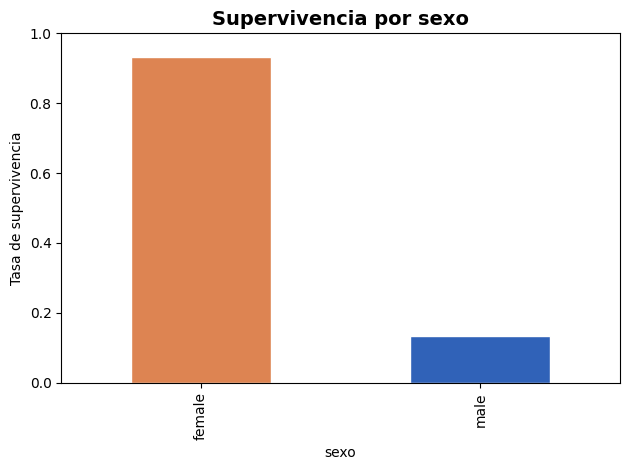

In [34]:
supervivencia_sexo = titianic_nuevo.groupby("sexo")["sobrevivio"].mean()

plt.Figure(figsize=(6,4))
supervivencia_sexo.plot(kind="bar", color=["#DD8452", "#3062B8"], edgecolor = "white", width = 0.5)
plt.title("Supervivencia por sexo", fontsize=14, fontweight = "bold")
plt.xlabel("sexo")
plt.ylabel("Tasa de supervivencia")
plt.ylim(0,1)
plt.tight_layout()
plt.show()
